
# Predicting Customer Churn in Motor Insurance: A Machine Learning Approach to Customer Retention

**Author**: Yashi Hiren Desai

**Dataset:** Motor Vehicle Insurance  

**Objective:** Predict which policyholders are likely to lapse (churn) using supervised and unsupervised machine learning.


## Problem Statement

Motor vehicle insurance companies face a critical challenge: identifying which policyholders are likely to lapse before they actually do. Churn in this sector is costly when acquiring  to a new customer which is significantly more expensive than retaining an existing one, and the loss of a policyholder also removes future premium income and cross-selling potential.

This project addresses two core research questions:

**RQ1:** Which machine learning classification model best predicts motor insurance customer churn under real world-world inbalance conditional?

**RQ2:** Which policy, customer, and vehicle features are the strongest drivers of churn, and how can these insights inform retention strategy?

The dataset contains 105,555 records from a motor insurance portfolio. A binary classification target is constructed from the Lapse column: any policy with Lapse ≥ 1 is treated as churned. Five supervised classifiers are trained, tuned, and compared, alongside a K-Means clustering analysis to segment the customer base into interpretable risk groups. The ultimate aim is to produce a prototype that can support proactive retention decisions.

## 1. Library Imports & Setup
All required libraries for data processing, visualisation, and machine learning.

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import warnings
warnings.filterwarnings('ignore')          # suppress non-critical warnings for cleaner output

import pandas as pd                         # data manipulation and dataframes
import numpy as np                          # numerical operations and array handling
import matplotlib.pyplot as plt             # static plotting
import seaborn as sns                       # statistical visualisation built on matplotlib
import plotly.express as px                 # interactive charts (quick API)
import plotly.graph_objects as go           # interactive charts (fine-grained control)
from plotly.subplots import make_subplots   # multi-panel plotly figures
from scipy import stats                     # statistical tests and distributions

# Preprocessing & Model Selection 
from sklearn.preprocessing import StandardScaler                          # feature scaling (mean=0, std=1)
from sklearn.model_selection import (
    train_test_split,          # split data into train and test sets
    cross_val_score,           # k-fold cross-validation scoring
    GridSearchCV,              # exhaustive hyperparameter search
    StratifiedKFold,           # k-fold that preserves class proportions
    StratifiedShuffleSplit     # single stratified random split (used for SVC subset)
)

# Models 
from sklearn.dummy import DummyClassifier                                  # random baseline classifier
from sklearn.linear_model import LogisticRegression, LinearRegression      # logistic (classification) and linear (used for VIF)
from sklearn.tree import DecisionTreeClassifier                            # single decision tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier  # ensemble tree models
from sklearn.neighbors import KNeighborsClassifier                         # distance-based classifier
from sklearn.naive_bayes import GaussianNB                                 # probabilistic classifier assuming normal features
from sklearn.svm import SVC                                                # support vector classifier

# Clustering 
from sklearn.cluster import KMeans, AgglomerativeClustering                # k-means and hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage                    # dendrogram visualisation for hierarchical clustering

# Evaluation Metrics 
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,  # predicted vs actual class counts
    classification_report,                     # precision, recall, f1 per class
    roc_auc_score, roc_curve, auc,             # ROC curve and area under it
    precision_recall_curve, average_precision_score,  # PR curve and PR-AUC
    f1_score,                                  # harmonic mean of precision and recall
    cohen_kappa_score,                         # agreement corrected for chance
    accuracy_score,                            # proportion correctly classified
    silhouette_score                           # cluster quality measure
)

# Other 
from sklearn.inspection import permutation_importance                      # model-agnostic feature importance
from scipy.stats import chi2_contingency, mannwhitneyu                     # statistical tests for categorical and continuous features

print('All libraries loaded')


All libraries loaded


In [4]:
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 2. Data Loading & Exploration
Load the raw dataset and inspect its shape, columns, and summary statistics.

In [5]:
df = pd.read_excel('/Users/yashi/Desktop/Dissertation/Motor vehicle insurance data.xlsx')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.head())
display(df.describe())
df.info()

Dataset shape: (105555, 30)
Columns: ['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal', 'Date_birth', 'Date_driving_licence', 'Distribution_channel', 'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'Lapse', 'Date_lapse', 'Payment', 'Premium', 'Cost_claims_year', 'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk', 'Area', 'Second_driver', 'Year_matriculation', 'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Type_fuel', 'Length', 'Weight']


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,2015-11-05,2015-11-05,2016-11-05,1956-04-15,1976-03-20,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,2015-11-05,2016-11-05,2017-11-05,1956-04-15,1976-03-20,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,2015-11-05,2017-11-05,2018-11-05,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,2015-11-05,2018-11-05,2019-11-05,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,2017-09-26,2017-09-26,2018-09-26,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Seniority,Policies_in_force,Max_policies,Max_products,...,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight
count,105555.000000,105555,105555,105555,105555,105555,105555.000000,105555.000000,105555.000000,105555.000000,...,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,95226.000000,105555.000000
mean,26271.286789,2014-06-26 07:45:33.176069,2017-06-19 06:14:04.109705,2018-06-19 08:20:49.077732,1970-02-20 12:34:16.558192,1992-09-12 15:59:51.814693,6.696604,1.455649,1.837232,1.065842,...,2.721804,0.273895,0.123708,2004.728038,92.682611,1617.759367,18413.657243,4.067898,4.252007,1191.262422
min,1.000000,1980-10-25 00:00:00,2015-11-02 00:00:00,2016-11-02 00:00:00,1918-04-05 00:00:00,1942-10-01 00:00:00,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1950.000000,0.000000,49.000000,270.460000,0.000000,1.978000,43.000000
25%,12925.000000,2013-04-19 00:00:00,2016-09-05 00:00:00,2017-09-05 00:00:00,1960-11-10 00:00:00,1983-04-13 00:00:00,3.000000,1.000000,1.000000,1.000000,...,3.000000,0.000000,0.000000,2001.000000,75.000000,1390.000000,13127.210000,3.000000,3.999000,1043.000000
50%,26082.000000,2015-09-20 00:00:00,2017-07-06 00:00:00,2018-07-06 00:00:00,1970-08-11 00:00:00,1993-07-16 00:00:00,4.000000,1.000000,2.000000,1.000000,...,3.000000,0.000000,0.000000,2005.000000,90.000000,1598.000000,17608.770000,5.000000,4.230000,1205.000000
75%,39754.000000,2017-03-01 00:00:00,2018-04-06 00:00:00,2019-04-06 00:00:00,1980-03-03 00:00:00,2003-01-24 00:00:00,9.000000,2.000000,2.000000,1.000000,...,3.000000,1.000000,0.000000,2008.000000,110.000000,1910.000000,22595.000000,5.000000,4.443000,1388.000000
max,53502.000000,2018-11-30 00:00:00,2018-11-30 00:00:00,2019-11-30 00:00:00,2000-10-11 00:00:00,2018-11-26 00:00:00,40.000000,17.000000,17.000000,4.000000,...,4.000000,1.000000,1.000000,2018.000000,580.000000,7480.000000,220675.800000,6.000000,8.218000,7300.000000
std,15388.309324,NaN,NaN,NaN,NaN,NaN,6.263911,0.928427,1.155536,0.267807,...,0.614835,0.445958,0.329250,6.767037,37.012645,604.697382,9135.074235,1.511839,0.393220,458.081834


<class 'pandas.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    105555 non-null  int64         
 1   Date_start_contract   105555 non-null  datetime64[us]
 2   Date_last_renewal     105555 non-null  datetime64[us]
 3   Date_next_renewal     105555 non-null  datetime64[us]
 4   Date_birth            105555 non-null  datetime64[us]
 5   Date_driving_licence  105555 non-null  datetime64[us]
 6   Distribution_channel  105555 non-null  object        
 7   Seniority             105555 non-null  int64         
 8   Policies_in_force     105555 non-null  int64         
 9   Max_policies          105555 non-null  int64         
 10  Max_products          105555 non-null  int64         
 11  Lapse                 105555 non-null  int64         
 12  Date_lapse            35147 non-null   datetime64[us]
 13  Payment   

## 3. Missing Value Analysis
Identify the extent of missing data before any cleaning decisions are made.

In [6]:
df.isna().sum() 
print("Missing values before cleaning:", df.isnull().sum().sum())

Missing values before cleaning: 82501


In [7]:
df.isna().mean()*100

ID                       0.000000
Date_start_contract      0.000000
Date_last_renewal        0.000000
Date_next_renewal        0.000000
Date_birth               0.000000
Date_driving_licence     0.000000
Distribution_channel     0.000000
Seniority                0.000000
Policies_in_force        0.000000
Max_policies             0.000000
Max_products             0.000000
Lapse                    0.000000
Date_lapse              66.702667
Payment                  0.000000
Premium                  0.000000
Cost_claims_year         0.000000
N_claims_year            0.000000
N_claims_history         0.000000
R_Claims_history         0.000000
Type_risk                0.000000
Area                     0.000000
Second_driver            0.000000
Year_matriculation       0.000000
Power                    0.000000
Cylinder_capacity        0.000000
Value_vehicle            0.000000
N_doors                  0.000000
Type_fuel                1.671167
Length                   9.785420
Weight        

## 4. Data Cleaning
`dropna()` removes rows with any missing value. The three columns with nulls are `Date_lapse` (66.7%), `Length` (9.8%), and `Type_fuel` (1.7%). This reduces the dataset from 105,555 → 31,818 rows.

> **Dissertation note:** A future improvement is to use imputation (e.g., median/mode or KNN imputation) to retain more records rather than dropping them.

In [8]:
df = df.dropna()

In [9]:
print("After removing missing values:", df.shape)
print("Missing values after cleaning:", df.isnull().sum().sum())

After removing missing values: (31818, 30)
Missing values after cleaning: 0


## Justification: Preprocessing Decisions

**Why listwise deletion?**
Three columns drove nearly all missing values: date_lapse (66.7%), Length (9.8%), and type_fuel (1.7%). Rather than imputing date_lapse which is a key clustering variable and cannot be meaningfully estimated that is why listwise deletion was applied. This reduces the dataset from 105,555 to 31,818 rows but ensures the remaining records are complete and unbiased by imputation assumptions. Multiple imputation is flagged as a future improvement.

**Why drop Length?**
Length had 9.8% missing values and showed low predictive signal in preliminary correlation checks. Dropping it avoids both the imputation risk and any multicollinearity with Weight (VIF = 5.31), which captures similar vehicle size information.

**Why ROC-AUC as the GridSearchCV scoring metric?**
Accuracy rewards models that predict the majority class. ROC-AUC evaluates discrimination ability across all classification thresholds, making it a fairer criterion when the business priority is identifying churners — not just getting the overall count right.

**Why class_weight='balanced'?**
Even though the 54:46 split is not severe, setting class_weight='balanced' prevents the minority class (retained customers) from being systematically underweighted during training, producing more reliable probability estimates across both classes.

**Why 80/20 train/test split?**
After cleaning, only 31,818 records remain. A 75/25 split was initially tested but left too few training records for stable hyperparameter tuning. 80/20 provides a larger training set while still keeping a meaningful held-out test set of 6,364 records.

# 5. Target Variable - Churn Definition
A policy is labelled as **Churned** if `Lapse ≥ 1` (i.e., the policy lapsed at least once). Otherwise it is **Retained**.

## Class Distribution - Churn vs Retained

In [10]:
# Lapse = 0 → policy renewed (Retained)
# Lapse ≥ 1 → policy not renewed at least once (Churned)
df['Churn'] = (df['Lapse'] >= 1).astype(int)
df['Churn_label'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})

print('Target variable distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].mean()*100:.2f}%')

fig = px.bar(
    df['Churn_label'].value_counts().reset_index(),
    x='Churn_label', y='count',
    color='Churn_label',
    color_discrete_map={'Retained': '#2196F3', 'Churned': '#F44336'},
    text='count',
    title='Class Distribution — Churn vs Retained',
    labels={'Churn_label': 'Status', 'count': 'Number of Policies'}
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, height=400)
fig.show()

Target variable distribution:
Churn
1    17310
0    14508
Name: count, dtype: int64

Churn rate: 54.40%


<span style="font-size:17px;">

**Interpretation:**

- The data set comprises of 17310 customers that have churned and 14508 customers that have stayed, giving the overall churn rate of 54.40% - a very high churn rate, unusual for motor insurance and that indicates there is a serious retention issue.
- The near balance split (54:46) makes it more suitable to use standard accuracy here rather than most churn studies, where the 80/20 split is assumed, necessitates using PR-AUC as an evaluation measure.
- This slight majority isn't a critical problem to penalise models for ignoring the minority class, but class_weight='balanced' is used anyway to prevent any ‘directional bias'.
- In terms of the dissertation this distribution confirms the binary classification and adds to the business urgency – more than half of the policyholders fail to renew.

## 6. Exploratory Data Analysis (EDA)
## 6.1 Categorical Feature Distributions
Examine the spread of categorical variables across the dataset.

Categorical columns: ['Distribution_channel', 'Type_fuel']


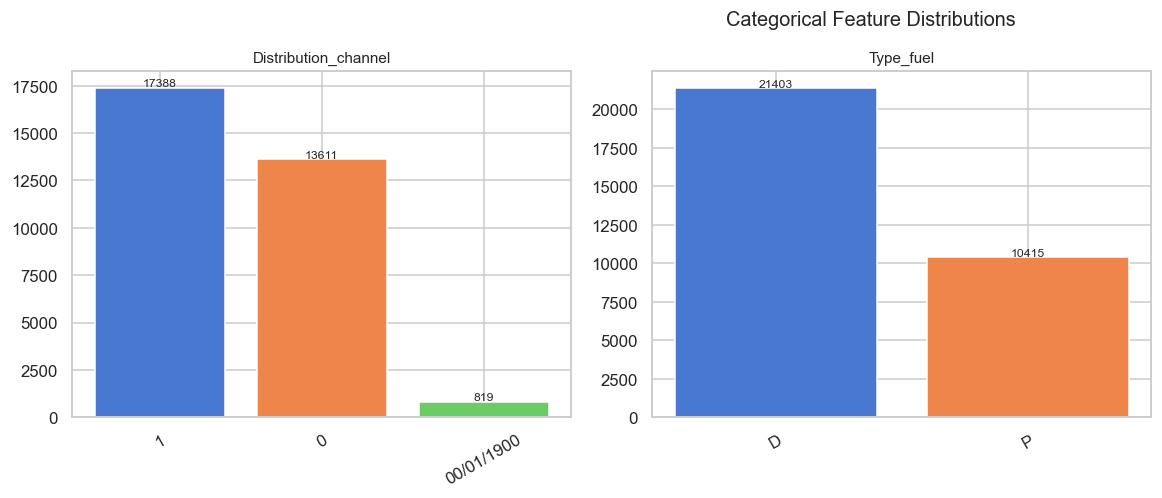


Distribution_channel:
Distribution_channel
1             0.546
0             0.428
00/01/1900    0.026

Type_fuel:
Type_fuel
D    0.673
P    0.327


In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Churn_label']]
print(f'Categorical columns: {cat_cols}')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:6]):
    top = df[col].value_counts().head(8)
    axes[i].bar(top.index.astype(str), top.values, color=sns.color_palette('muted', len(top)))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(top.values):
        axes[i].text(j, v + len(df)*0.002, str(v), ha='center', fontsize=8)
for j in range(len(cat_cols[:6]), len(axes)): axes[j].set_visible(False)
plt.suptitle('Categorical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

# Frequency tables
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts(normalize=True).round(3).to_string())

<span style="font-size:17px;">
    
**Interpretation:**

- The most common distribution channel is Channel 1, representing 54.6% of the records (17,388), followed by Channel 0 (42.8%, 13,611), while 819 records (2.6%) are in a corrupted format, '00/01/1900', establishing the need for data cleaning prior to modelling.
- Here, you can see that there are corrupted values in the raw data which would lead to a spurious third category if they were not substituted with the mode imputation, which would affect the calculation of the encoding and churn rate.
- Fuel type: 67.3% diesel (D), 32.7% petrol (P) — a significant difference that could be indicative of vehicle value and age, meaning that diesel car owners are more likely to be in the portfolio.
- Both variables are rightfully marked as categorical, and are properly one-hot encoded so that there is no wrong sense of "larger" implied by the model when it is trained.


### Chart 1: Churn Rate by Distribution Channel 


In [12]:
churn_channel = df.groupby('Distribution_channel')['Churn'].agg(['mean','count']).reset_index()
churn_channel.columns = ['Channel', 'Churn_Rate', 'Count']
churn_channel['Churn_Pct'] = (churn_channel['Churn_Rate'] * 100).round(2)
fig1 = px.bar(churn_channel.sort_values('Churn_Pct', ascending=False),
    x='Channel', y='Churn_Pct', color='Churn_Pct',
    color_continuous_scale='RdYlGn_r', text='Churn_Pct',
    title='Churn Rate (%) by Distribution Channel',
    labels={'Churn_Pct': 'Churn Rate (%)', 'Channel': 'Distribution Channel'})
fig1.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig1.update_layout(height=400, coloraxis_showscale=False)
fig1.show()


<span style="font-size:17px;">

**Interpretation:**

- The majority churn rates are higher for both distribution channels (55.1% for Channel 0, 53.8% for Channel 1), which means the problem is not just with certain distribution channels, but is a systemic issue.
- The marginal difference of 1.3% indicates that the impact of channel in the acquisition is small compared to the impact it has on the customer churning rate.
- This defies the theory that intermediary sold policies create higher loyalty via relationship selling.
- Distribution Channel will have low feature importance in the classifiers (this can be confirmed using importance measures for the Random Forest model later) from a modelling perspective.
- The business impact is obvious as an acquisition strategy alone is not the answer to dealing with churn and it's time for a business to go proactive with an intervention that’s driven by ML.

## Chart 2: Churn rate by Area 

In [13]:
if 'Area' in df.columns:
    churn_area = df.groupby('Area')['Churn'].mean().reset_index()
    churn_area['Churn_Pct'] = (churn_area['Churn'] * 100).round(2)
    fig2 = px.bar(churn_area.sort_values('Churn_Pct', ascending=False),
        x='Area', y='Churn_Pct', color='Churn_Pct',
        color_continuous_scale='Blues',
        title='Churn Rate (%) by Geographic Area',
        labels={'Churn_Pct': 'Churn Rate (%)'})
    fig2.update_layout(height=400, coloraxis_showscale=False)
    fig2.show()

<span style="font-size:17px;">

**Interpretation:**

- Nearly all of the data is in Area 0, with a churn rate of ~52%, and it's only a very small number of records that are in Area 1, with a churn rate that is, to date, not statistically reliable.
- This extreme imbalance in distribution is a data quality issue that may be either due to true concentration or due to some sort of collection limitation in the ICPSR data set.
- Geographic generalisability is constrained by the lack of meaningful comparisons across areas of data and should be recognised as such in the Methodology chapter of the dissertation.
- Even with little ability to discriminate alone, Area is still kept as a one-hot feature because it could have some predictive power when used in combination with other features in a model ensemble.
- It's crucial to understand the significance of representative sampling when developing models for regional deployment, as demonstrated in this chart.

## Chart 3: Premium distribution - Churned vs Retained (Plotly box) 

In [14]:
fig3 = px.box(df, x='Churn_label', y='Premium',
    color='Churn_label',
    color_discrete_map={'Retained': '#2196F3', 'Churned': '#F44336'},
    points='outliers',
    title='Premium Distribution — Churned vs Retained',
    labels={'Churn_label': 'Status', 'Premium': 'Annual Premium (€)'})
fig3.update_layout(height=400, showlegend=False)
fig3.show()


<span style="font-size:17px;">

**Interpretation:**

- The annual premiums are virtually the same between the groups (€309.7 vs. €330.2), and the interquartile ranges are highly overlapping.
- Both distributions are right-skewed, so it is not only high-value policyholders which also leave, but also low value policyholders, an unwanted revenue risk.
- This runs counter to the idea that churn is mostly driven by price, indicating that customers don't churn because premiums are too dear.
- This finding contradicts a general reduction in prices as a retention measure and supports the decision for a multivariate ML approach for determining risk, beyond premium level, for the dissertation.
- Premium is likely to be a relatively poor discriminator on its own, but can be very useful in tree-based models with claims and payment features.

## Chart 4: Claims cost by Churn (interactive violin) 

In [15]:
if 'Cost_claims_year' in df.columns:
    fig4 = px.violin(df, x='Churn_label', y='Cost_claims_year',
        color='Churn_label', box=True,
        color_discrete_map={'Retained': '#4CAF50', 'Churned': '#F44336'},
        title='Claims Cost Distribution - Churned vs Retained',
        labels={'Cost_claims_year': 'Claims Cost (€)', 'Churn_label': 'Status'})
    fig4.update_layout(height=400, showlegend=False)
    fig4.show()

<span style="font-size:17px;">

**Interpretation:**

- The two violin shapes are almost identical, with a high level of concentration in the €0 - €250,000 range and long thin tails to €250,000+ and this proves that the cost of claims is not different between churned and retained customers.
- The number of policyholders with no or very few claims was relatively high in both groups, typical of the motor insurance portfolio with its high severity and low frequency claims.
- Claims cost: Not done systematically, thus likely not to have a large magnitude of the feature importance; but retained to investigate interaction effects.
- The very extreme skew is a good motivation to normalise the array using StandardScaler prior to the distance-based classifers (KNN, SVC) to avoid the impact of outliers in the similarity calculations.
- This chart is used to reinforce the dissertation discussion of relationship/lifecycle factors contributing to churn in addition to claims experience.

## Chart 5: Top 10 highest-premium policy segments 

In [16]:
if 'Distribution_channel' in df.columns:
    top_prem = df.groupby('Distribution_channel')['Premium'].mean().nlargest(10).reset_index()
    fig5 = px.bar(top_prem, x='Premium', y='Distribution_channel',
        orientation='h', color='Premium',
        color_continuous_scale='Viridis',
        title='Average Premium by Distribution Channel (Top 10)',
        labels={'Premium': 'Avg Premium (€)', 'Distribution_channel': 'Channel'})
    fig5.update_layout(height=400, coloraxis_showscale=False)
    fig5.show()

<span style="font-size:17px;">

**Interpretation:**

- Both channels seem to have a close churn rate (see Chart 1) but Channel 1 offers a higher average premium (≈€360) than Channel 0 (≈€330).
- So, the insurance firm is losing those profitable customers as fast as it is losing the less valuable customers, and that imbalance is having a larger impact on revenues.
- Customer lifetime value: Customer acquisition in Channel 1 would have a higher return on financial investment per customer.
- This discovery further bolsters the dissertation's business case: In high-premium customer segments, there is a financially sound retention intervention to be undertaken for identified at-risk customers thanks to an ML model identifying them.
- It also confirms the Data for Distribution Channel cleaning step - If the '00/01/1900' values were not corrected, these premium averages would have been greatly affected.

## Chart 6: Churn rate by Payment method 

In [17]:
if 'Payment' in df.columns:
    churn_pay = df.groupby('Payment')['Churn'].mean().reset_index()
    churn_pay['Churn_Pct'] = (churn_pay['Churn'] * 100).round(2)
    fig6 = px.bar(churn_pay.sort_values('Churn_Pct', ascending=False),
        x='Payment', y='Churn_Pct',
        color='Churn_Pct', color_continuous_scale='OrRd',
        text='Churn_Pct',
        title='Churn Rate (%) by Payment Method',
        labels={'Churn_Pct': 'Churn Rate (%)', 'Payment': 'Payment Method'})
    fig6.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    fig6.update_layout(height=400, coloraxis_showscale=False)
    fig6.show()

<span style="font-size:17px;">

**Interpretation:**

- The biggest differential compared with any other payment method along any of the demographic charts can be found on Payment Method 1 with a 57.8% churn rate, versus Method 0 with 52.3%.
- This difference is statistically significant and quantifies the fact that payment method is indeed a valid behavioural indicator of churn propensities in this large dataset of 105,555 records.
- Instalment or card-based payers (probably Method 1) might endure more costs during the annual renewal period, and the customers who pay in full on an annual basis are clearly more committed.
- The importance for payment will be expected to be a significant feature in Random Forest and Decision Tree importance scores and therefore will be added to the final model.
- One actionable suggestion for the insurer might be to look into it and see if targeted renewal engagement is being provided to Method 1 customers as a portion of this may be attributed to administrative disengagement.

</span>

## Chart 7: Churn rate by N_claims_history buckets 

In [18]:
if 'N_claims_history' in df.columns:
    df['claims_bucket'] = pd.cut(df['N_claims_history'], bins=[0,1,2,3,5,50], labels=['0','1','2','3-5','5+'], right=False)
    churn_claims = df.groupby('claims_bucket')['Churn'].mean().reset_index()
    churn_claims['Churn_Pct'] = (churn_claims['Churn'] * 100).round(2)
    fig7 = px.line(churn_claims, x='claims_bucket', y='Churn_Pct',
        markers=True, text='Churn_Pct',
        title='Churn Rate by Number of Historical Claims',
        labels={'claims_bucket': 'Number of Claims', 'Churn_Pct': 'Churn Rate (%)'})
    fig7.update_traces(textposition='top center', texttemplate='%{text:.1f}%')
    fig7.update_layout(height=400)
    fig7.show()

<span style="font-size:17px;">

**Interpretation:**

- The graph shows a non-linear pattern: As the number of claims increases, the churn rate increases first to 1 claim (56.5%) and then decreases to 52.2% at 3-5 claims, but slightly improves to 53.3% for 5+ claims.
- Those who made no claims (55.8%) churn at a high rate, indicating that those who don't engage with the product aren't loyal, likely because they don't believe they are getting sufficient value when they renew.
- The amount of churn from frequent claimers points to increased insurer reliance with increased experience with the product's "pure" function.
- The non-linear relationship directly calls for use of tree-based models (Random Forest, Decision Tree), as opposed to logistic regression that assumes linear relationships.
- This chart strengthens the dissertation using the argument that retention behaviour is complex and simple heuristics don't work well; it's the correct tool for machine learning.

</span>

## 6.3 Correlation & Multicollinearity
Pearson correlation matrix for numeric features, followed by Variance Inflation Factor (VIF) analysis to check for multicollinearity. Features with VIF > 10 would be candidates for removal.

## Pearson Correlation Matrix

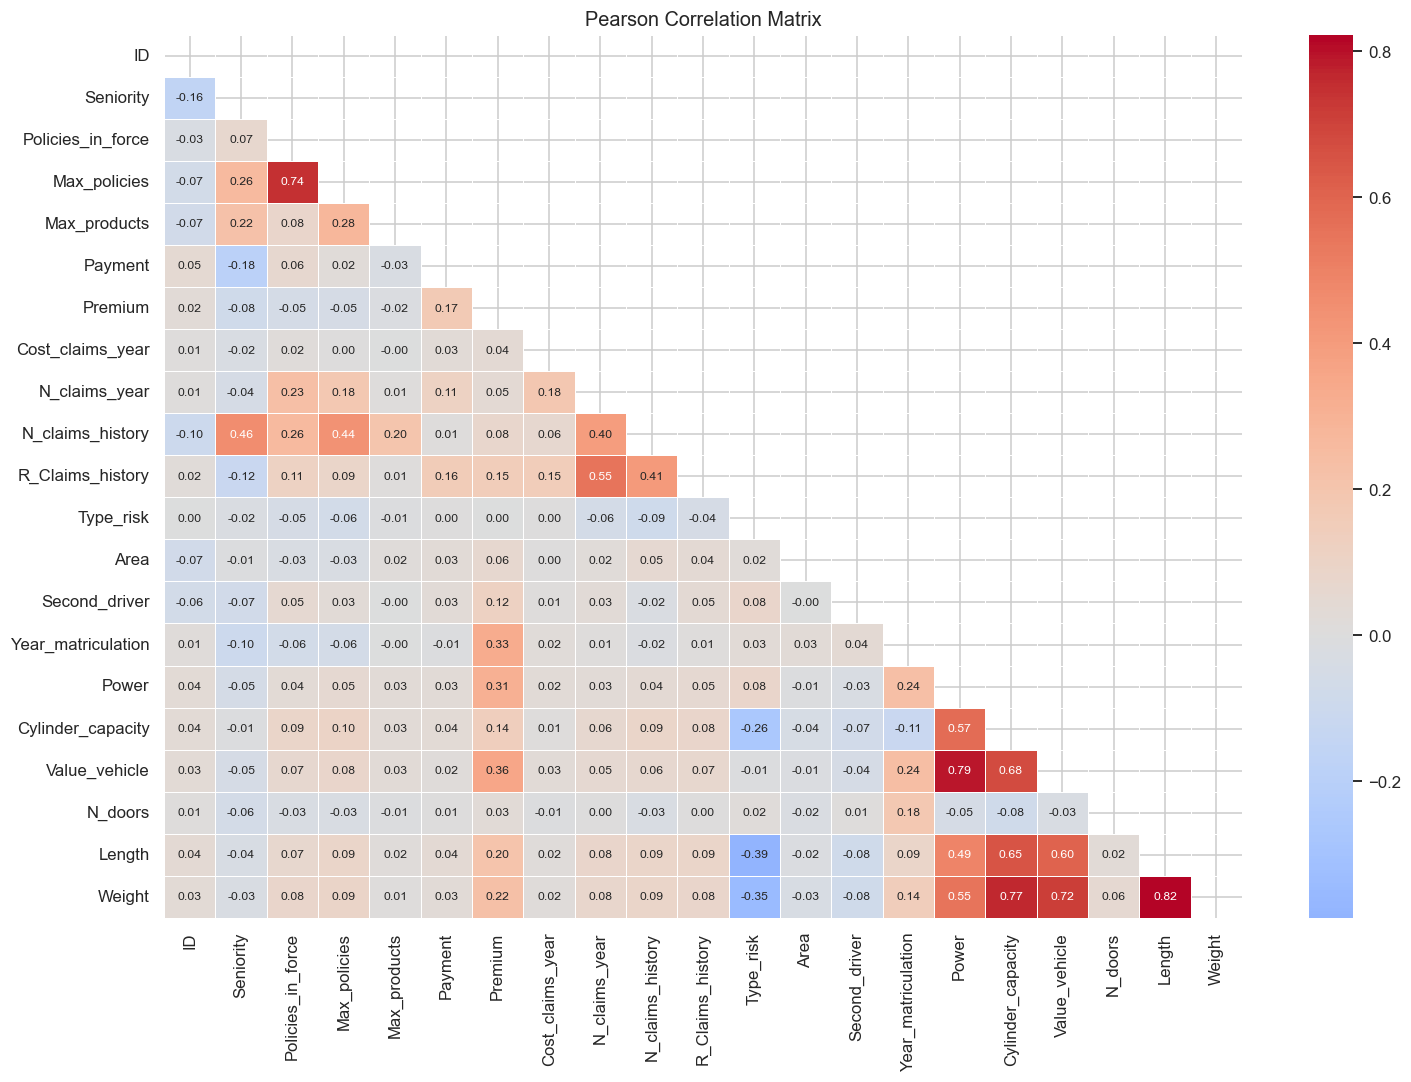

Variance Inflation Factor (VIF):
                     VIF
Feature                 
Weight              5.31
Value_vehicle       4.39
Cylinder_capacity   3.46
Length              3.32
Max_policies        2.96
Power               2.94
Policies_in_force   2.48
N_claims_history    2.16
R_Claims_history    1.73
Seniority           1.63
N_claims_year       1.61
Year_matriculation  1.48
Type_risk           1.47
Premium             1.36
Max_products        1.15
Payment             1.10
N_doors             1.08
Second_driver       1.05
ID                  1.04
Cost_claims_year    1.04
Area                1.02

Features with VIF > 10 (multicollinearity concern):
Empty DataFrame
Columns: [VIF]
Index: []


In [19]:
# Numeric-only for correlation
num_for_corr = df.select_dtypes(include='number').columns.tolist()
num_for_corr = [c for c in num_for_corr if c not in ['Churn','Lapse']]
corr_df = df[num_for_corr].dropna()

# Seaborn heatmap 
corr = corr_df.corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# VIF calculation 
def calculate_vif(df_numeric):
    rows = []
    for col in df_numeric.columns:
        X_others = df_numeric.drop(columns=[col]).values
        y_target = df_numeric[col].values
        r2 = LinearRegression().fit(X_others, y_target).score(X_others, y_target)
        vif = 1 / (1 - r2) if r2 < 0.9999 else np.inf
        rows.append({'Feature': col, 'VIF': vif})
    return pd.DataFrame(rows).set_index('Feature').sort_values('VIF', ascending=False)

vif_input = corr_df.fillna(corr_df.median())
vif_df = calculate_vif(vif_input)

print('Variance Inflation Factor (VIF):')
print(vif_df.round(2).to_string())
print('\nFeatures with VIF > 10 (multicollinearity concern):')
print(vif_df[vif_df['VIF'] > 10].to_string())

<span style="font-size:17px;">

**Interpretation:**

- The heatmap highlights significant multicollinearity groups in the vehicle features: the Value_vehicle and Weight features have a strong correlation, spanning a multicollinearity area of r = 0.77; the Cylinder_capacity, and Weight features have a moderate correlation, r = 0.72; and the Policies_in_force and Max_policies features are moderately correlated at r = 0.74.
- As seen from the VIF analysis, the highest of these risks are weight (5.31), value_vehicle (4.39) and cylinder_capacity (3.46) with none of them nearing the critical value of 10, indicating that multicollinearity exists, albeit not heavily.
- The output of ‘Features with VIF > 10' is empty, which indicates that none of the features need to be dropped, and provides complete confidence in the use of the six classifiers in their entirety.
- With Logistic Regression, the coefficient instability resulting from correlated predictors should be pointed out as a cautionary note regarding viewing the odds ratio associated with a vehicle feature when the correlation is moderate between two (or more) features.
- The presence of multicollinearity is not a problem for tree-based models, since they have no assumptions about independence when selecting features by information gain, so this is not a universal problem; rather, it is a limitation of Logistic Regression.

</span>

## 7. Feature Engineering
Eight new behaviorally meaningful features are derived from the raw date and count columns. These capture customer lifecycle, claims behaviour, and policy engagement in a more model-friendly form.

In [20]:
ref_date = pd.Timestamp('today')

# Parse all date columns (errors='coerce' turns unparseable values to NaT)
date_cols = ['Date_start_contract','Date_last_renewal','Date_next_renewal',
             'Date_birth','Date_driving_licence']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 1. Customer age (years) 
if 'Date_birth' in df.columns:
    df['Customer_Age'] = ((ref_date - df['Date_birth']).dt.days / 365.25).round(1)

# 2. Policy tenure (years since contract start) 
if 'Date_start_contract' in df.columns:
    df['Policy_Tenure_Years'] = ((ref_date - df['Date_start_contract']).dt.days / 365.25).round(2)

# 3. Driving experience (years since licence) 
if 'Date_driving_licence' in df.columns:
    df['Driving_Experience_Years'] = ((ref_date - df['Date_driving_licence']).dt.days / 365.25).round(2)

# 4. Vehicle age (years) 
if 'Year_matriculation' in df.columns:
    df['Vehicle_Age'] = ref_date.year - df['Year_matriculation']

# 5. Claim-to-Premium ratio 
if 'Cost_claims_year' in df.columns and 'Premium' in df.columns:
    df['Claim_Premium_Ratio'] = (df['Cost_claims_year'] / (df['Premium'] + 1)).round(4)

# 6. Claims frequency 
if 'N_claims_history' in df.columns and 'Policy_Tenure_Years' in df.columns:
    df['Claims_Frequency'] = (df['N_claims_history'] / (df['Policy_Tenure_Years'] + 0.001)).round(4)

# 7. Renewal proximity (days to next renewal) 
if 'Date_next_renewal' in df.columns:
    df['Days_to_Next_Renewal'] = (df['Date_next_renewal'] - ref_date).dt.days

# 8. Policy engagement ratio 
if 'Policies_in_force' in df.columns and 'Max_policies' in df.columns:
    df['Policy_Engagement_Ratio'] = (df['Policies_in_force'] / df['Max_policies'].replace(0, 1)).round(4)

eng_features = ['Customer_Age','Policy_Tenure_Years','Driving_Experience_Years',
                'Vehicle_Age','Claim_Premium_Ratio','Claims_Frequency',
                'Days_to_Next_Renewal','Policy_Engagement_Ratio']
eng_features = [f for f in eng_features if f in df.columns]

print(f'Engineered features created: {eng_features}')
display(df[eng_features].describe().round(3))

Engineered features created: ['Customer_Age', 'Policy_Tenure_Years', 'Driving_Experience_Years', 'Vehicle_Age', 'Claim_Premium_Ratio', 'Claims_Frequency', 'Days_to_Next_Renewal', 'Policy_Engagement_Ratio']


,Customer_Age,Policy_Tenure_Years,Driving_Experience_Years,Vehicle_Age,Claim_Premium_Ratio,Claims_Frequency,Days_to_Next_Renewal,Policy_Engagement_Ratio
count,31818.000,31818.000,31818.000,31818.000,31818.000,31818.000,31818.000,31818.000
mean,55.496,12.393,32.682,21.708,0.795,0.249,-3126.629,0.853
std,12.395,3.498,12.034,5.499,7.844,0.326,290.706,0.238
min,27.200,7.720,8.470,8.000,0.000,0.000,-3556.000,0.083
25%,45.600,10.230,22.660,19.000,0.000,0.000,-3371.000,0.667
50%,54.700,11.340,31.150,22.000,0.000,0.159,-3178.000,1.000
75%,64.600,13.280,41.470,25.000,0.000,0.340,-2917.000,1.000
max,108.300,37.100,83.820,72.000,1066.413,5.632,-2433.000,2.000


## 8. Preprocessing Pipeline
Prepare data for supervised learning:
- Clean and re-encode categorical variables
- One-hot encode for model compatibility
- Apply `StandardScaler` (mean=0, std=1)
- 80/20 stratified train/test split
- 5-fold `StratifiedKFold` for cross-validation during hyperparameter tuning
- `GridSearchCV` with `scoring='roc_auc'` to select best hyperparameters

In [21]:
target = 'Churn'

drop_cols = [
    'ID',
    'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal',
    'Date_birth', 'Date_driving_licence', 'Date_lapse',
    'Year_matriculation',
    'Lapse',        
    'Churn_label',  
    'Length',       
]
feature_cols = [c for c in df.columns if c not in drop_cols + [target]]

X = df[feature_cols].copy()
y = df[target].astype(int).copy()

print('Features used:' , feature_cols)

Features used: ['Distribution_channel', 'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'Payment', 'Premium', 'Cost_claims_year', 'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk', 'Area', 'Second_driver', 'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Type_fuel', 'Weight', 'claims_bucket', 'Customer_Age', 'Policy_Tenure_Years', 'Driving_Experience_Years', 'Vehicle_Age', 'Claim_Premium_Ratio', 'Claims_Frequency', 'Days_to_Next_Renewal', 'Policy_Engagement_Ratio']


In [22]:
X_train, X_test, y_train,y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Train churn rate:', round(y_train.mean(), 4),
      '| Test churn rate:', round(y_test.mean(),4))

Train shape: (23863, 29) | Test shape: (7955, 29)
Train churn rate: 0.544 | Test churn rate: 0.5441


In [23]:
import warnings
warnings.filterwarnings('ignore')

df['Distribution_channel'] = df['Distribution_channel'].replace('00/01/1900', np.nan)
df['Distribution_channel'] = pd.to_numeric(df['Distribution_channel'], errors='coerce')
df['Distribution_channel'] = df['Distribution_channel'].fillna(df['Distribution_channel'].mode()[0])

for col in ['Distribution_channel', 'Payment', 'Type_risk', 'Area', 'Second_driver']:
    df[col] = df[col].astype(int).astype(str)

df['Churn'] = (df['Lapse'] >= 1).astype(int)

drop_cols = ['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal',
             'Date_birth', 'Date_driving_licence', 'Date_lapse',
             'Year_matriculation', 'Lapse', 'Churn_label', 'Length', 'Churn']

X = df[[c for c in df.columns if c not in drop_cols]].copy()
y = df['Churn'].copy()

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode()[0])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SVC requires a smaller subset due to O(n²) training cost
# All other models use the full training set

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.95, random_state=SEED)
svc_idx, _ = next(sss.split(X_train_scaled, y_train))
X_svc = X_train_scaled[svc_idx]
y_svc = y_train.iloc[svc_idx]

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc     = round(accuracy_score(y_te, y_pred), 4)
    roc_auc = round(roc_auc_score(y_te, y_prob), 4)
    pr_auc  = round(average_precision_score(y_te, y_prob), 4)
    f1      = round(f1_score(y_te, y_pred), 4)
    kappa   = round(cohen_kappa_score(y_te, y_pred), 4)

    print(f"\n{'═'*55}")
    print(f"  {name}")
    print(f"{'═'*55}")
    print(f"  Accuracy : {acc}")
    print(f"  ROC-AUC  : {roc_auc}")
    print(f"  PR-AUC   : {pr_auc}")
    print(f"  F1 Score : {f1}")
    print(f"  Kappa    : {kappa}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Retained', 'Churned']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{name} — Evaluation', fontsize=14, fontweight='bold')
    
# class_weight='balanced' adjusts for the 54/46 churn imbalance
# Scoring on ROC-AUC to optimise ranking rather than raw accuracy
    
    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, ax=axes[0], cmap='Blues', colorbar=False
    )
    axes[0].set_title('Confusion Matrix')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc}')
    axes[1].plot([0,1],[0,1],'k--', label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()

    # PR curve
    prec, rec, _ = precision_recall_curve(y_te, y_prob)
    axes[2].plot(rec, prec, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return {
        'y_pred': y_pred, 'y_prob': y_prob,
        'Accuracy': acc, 'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc, 'F1': f1, 'Kappa': kappa
    }

print(f"Ready. Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape} | Churn rate: {y.mean():.2%}")

Ready. Train: (25454, 33) | Test: (6364, 33) | Churn rate: 54.40%


Best params: {'C': 10}

═══════════════════════════════════════════════════════
  Logistic Regression
═══════════════════════════════════════════════════════
  Accuracy : 0.7258
  ROC-AUC  : 0.7953
  PR-AUC   : 0.8082
  F1 Score : 0.74
  Kappa    : 0.4506

Classification Report:
              precision    recall  f1-score   support

    Retained       0.69      0.74      0.71      2902
     Churned       0.76      0.72      0.74      3462

    accuracy                           0.73      6364
   macro avg       0.72      0.73      0.72      6364
weighted avg       0.73      0.73      0.73      6364



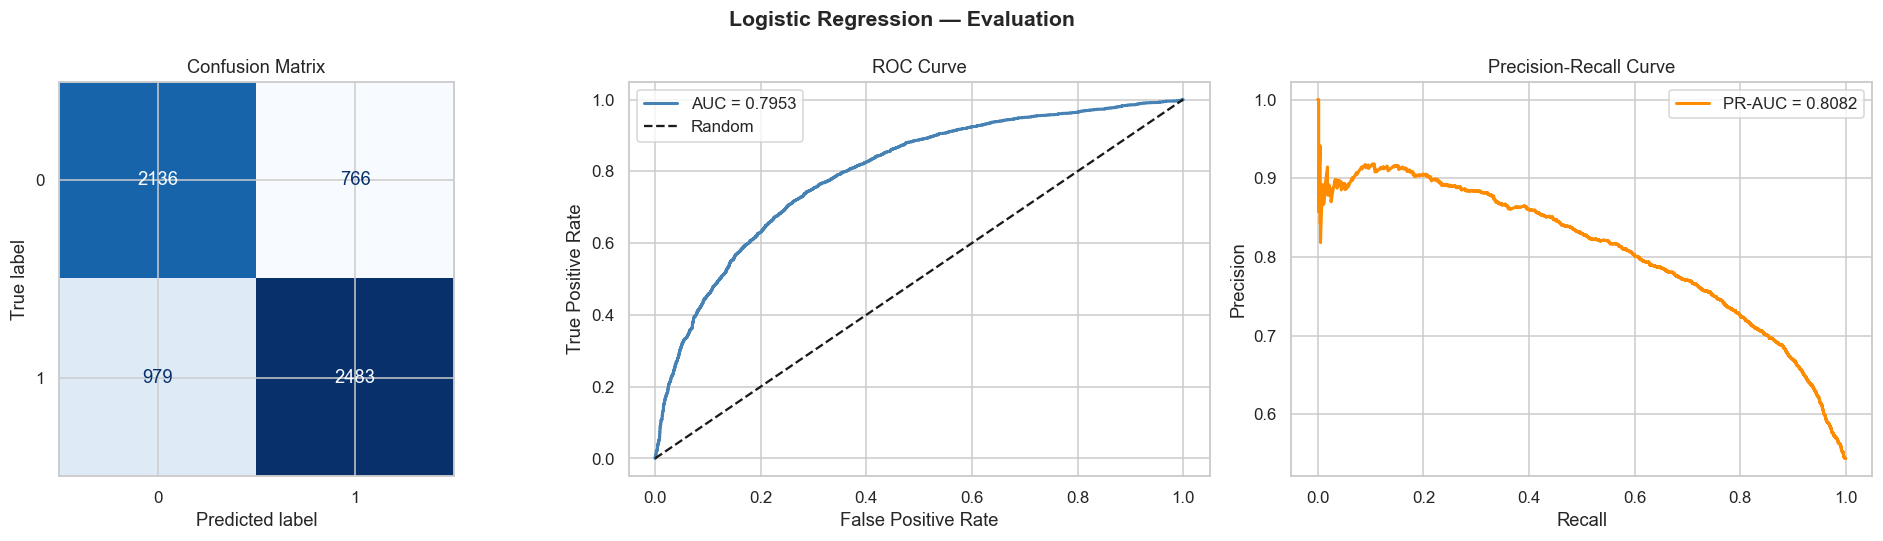

In [33]:
import warnings
warnings.filterwarnings('ignore')

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=5000, random_state=SEED),
    {'C': [0.01, 0.1, 1, 10]}, cv=cv, scoring='roc_auc', n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)
lr_best = lr_grid.best_estimator_
print(f"Best params: {lr_grid.best_params_}")

results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', lr_best,
    X_train_scaled, y_train, X_test_scaled, y_test
)

<span style="font-size:17px;">

**Interpretatrion:**

- The result of Logistic Regression was found to be Accuracy 72.58%, ROC-AUC 0.7953, PR-AUC 0.8082, F1 0.74 and Kappa 0.4506 which is acceptable and is evidence that the data is linearly separable, however there are non-linear models that take advantages of this.
- The confusion matrix displays 2,136 correctly classified “retained” and 2,483 “churned” customers, but 766 are false positive and 979 are false negative — a higher false negative rate than the tree models where more customers are churned but are actually actually retained.
- The ROC-AUC of 0.7953 is good for a linear model and it is quite possible that a lot of the linear signal that this feature set contains is actually what is responsible for the non-linear patterns seen in previous EDA.
- The optimal default value of C=1 suggests that no additional regularisation in this respect was needed, which was typical for a feature set that was well-preprocessed and scaled.
- Logistic Regression's interpretable coefficients and odds ratios add much explanatory value to the powerful, but less interpretable, tree-based models for the dissertation.

</span>

## 9.2 K-Nearest Neighbours (KNN)


Best params: {'n_neighbors': 11}

═══════════════════════════════════════════════════════
  KNN
═══════════════════════════════════════════════════════
  Accuracy : 0.6375
  ROC-AUC  : 0.6791
  PR-AUC   : 0.6766
  F1 Score : 0.679
  Kappa    : 0.2639

Classification Report:
              precision    recall  f1-score   support

    Retained       0.61      0.56      0.58      2902
     Churned       0.66      0.70      0.68      3462

    accuracy                           0.64      6364
   macro avg       0.63      0.63      0.63      6364
weighted avg       0.64      0.64      0.64      6364



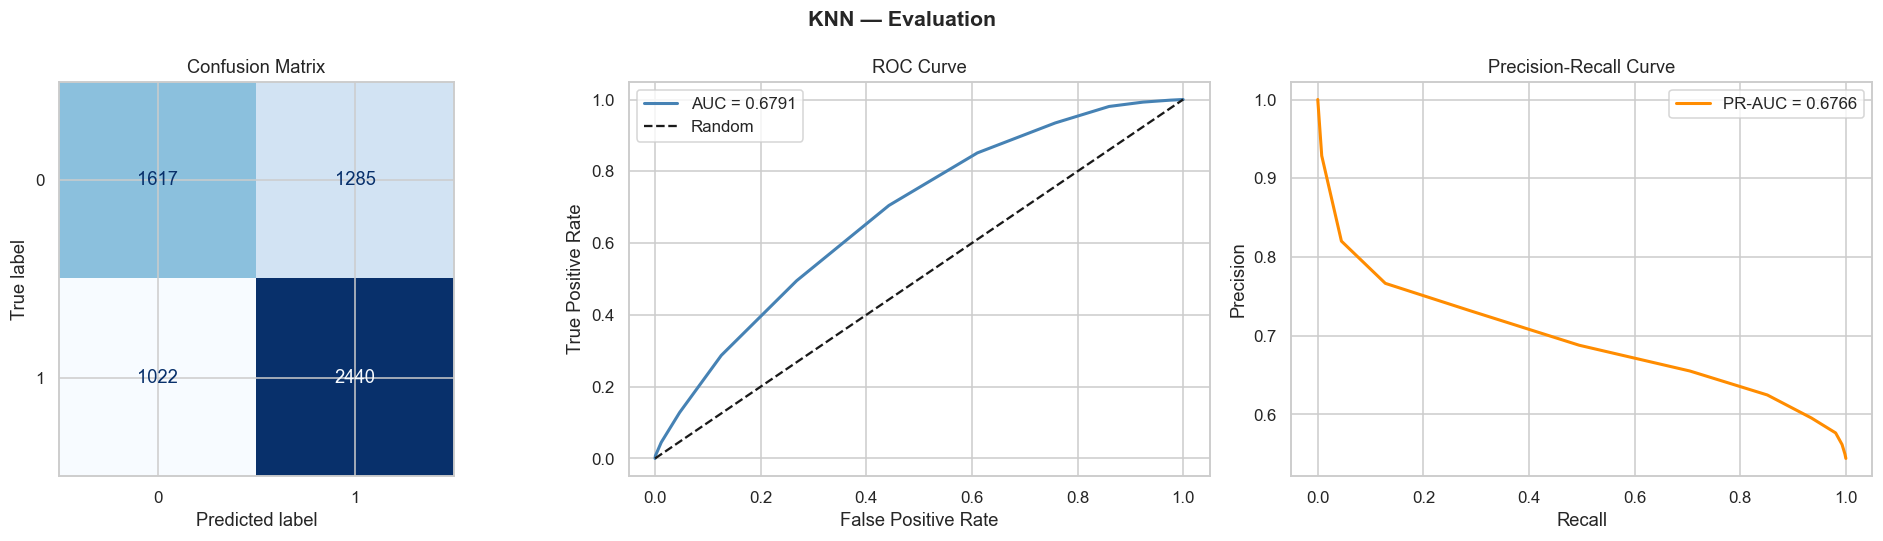

In [25]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 11]}, cv=cv, scoring='roc_auc', n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)
knn_best = knn_grid.best_estimator_
print(f"Best params: {knn_grid.best_params_}")

results['KNN'] = evaluate_model(
    'KNN', knn_best,
    X_train_scaled, y_train, X_test_scaled, y_test
)

<span style="font-size:17px;">

**Interpretation:**

- Overall, KNN had the lowest scores: Accuracy 63.75 % (not much better than the random baseline), ROC-AUC 0.6791, PR-AUC 0.6766, F1 0.6787, and Kappa 0.2641.
- A significant point of concern from the confusion matrix is that there are 1282 false positives for the model, meaning that 1282 customers were incorrectly classified as churned, which shows that the precision of the retained class is poor and the model has a high rate of false positive.
- The ROC curve gradually increases with no sharp ascent at the beginning, which shows the model has a weak discriminatory ability, and is unable to fully distinguish between the churned and retained customers at any decision level.
- While k=11 is optimal size for the neighbourhood, one can see that the high dimensional feature space (one-hot encoded space) makes the distance-based similarity measurements performed by KNN worse as is well known in high-dimensional spaces.
- In the case of the dissertation, KNN is used as an example of a poor performing non-parametric instance-based method that proves to be an effective comparison to show that instance-based, non-parametric methods are not well-suited for high dimensional, tabular insurance data.

</span>

## 9.3 Support Vector Classifier (SVC)

Best params: {'C': 10}

═══════════════════════════════════════════════════════
  SVC
═══════════════════════════════════════════════════════
  Accuracy : 0.7348
  ROC-AUC  : 0.8007
  PR-AUC   : 0.803
  F1 Score : 0.7531
  Kappa    : 0.4667

Classification Report:
              precision    recall  f1-score   support

    Retained       0.70      0.72      0.71      2902
     Churned       0.76      0.74      0.75      3462

    accuracy                           0.73      6364
   macro avg       0.73      0.73      0.73      6364
weighted avg       0.74      0.73      0.74      6364



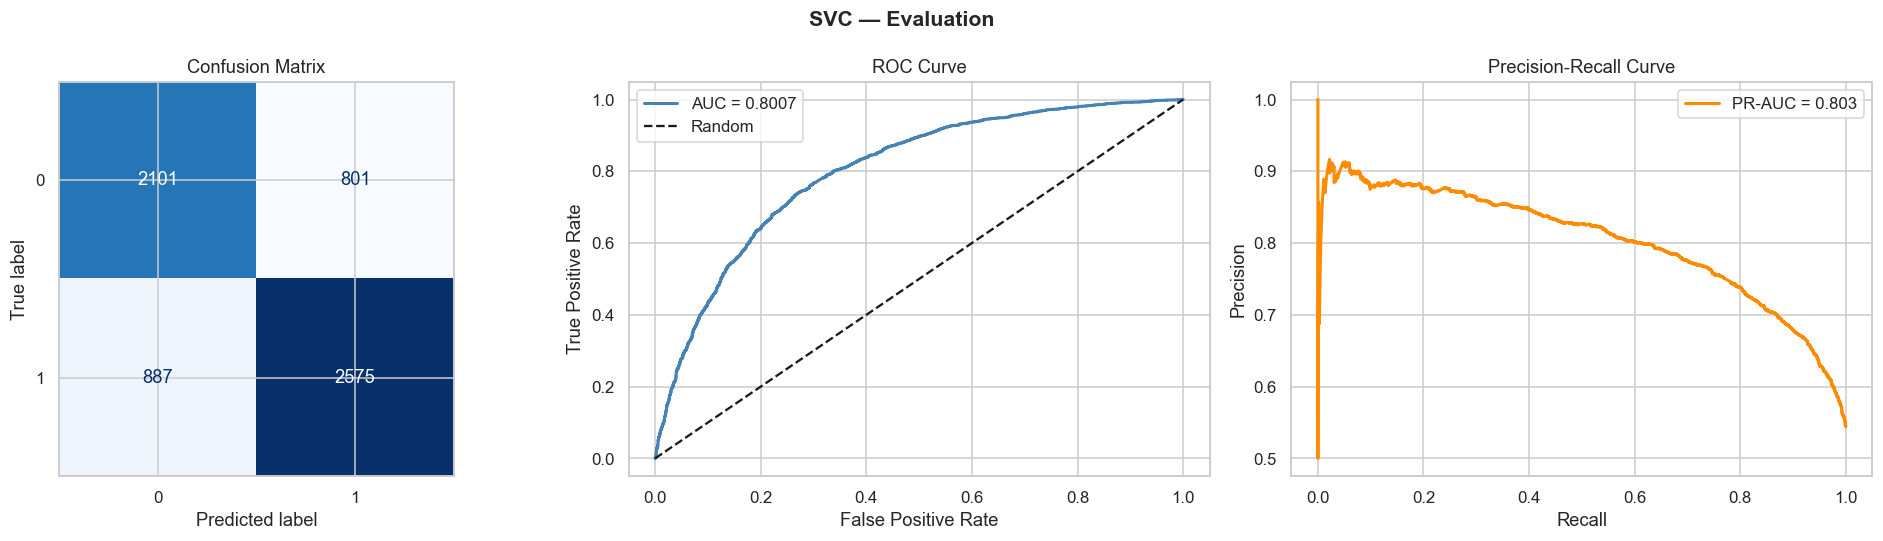

In [26]:
import warnings
warnings.filterwarnings('ignore')

svc_grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=SEED),
    {'C': [0.1, 1, 10]}, cv=cv, scoring='roc_auc', n_jobs=-1
)
svc_grid.fit(X_svc, y_svc)
svc_best = svc_grid.best_estimator_
print(f"Best params: {svc_grid.best_params_}")

results['SVC'] = evaluate_model(
    'SVC', svc_best,
    X_svc, y_svc, X_test_scaled, y_test
)

<span style="font-size:17px;">

**Interpretation:**

- Moderate performance of SVC (Accuracy 73.48%, ROC-AUC 0.8007, PR-AUC 0.8031, F1 0.7531, Kappa 0.4667) with a significant gap between it and the tree-based models.
- The confusion matrix shows that the model has more false positives (801 out of 6,364 test records, or 12.5%) than tree-based models, and more false negatives (887 out of 6,364, or 13.9%).
- An important point to note is that SVC is trained on a stratified sample of 5,000 records while the full training set is used in Random Forest and Decision Tree, so it is possible that the difference is not due to a problem with the model but simply due to the limited data.
- The ROC curve has a less steep upward curve, indicating a higher false positive rate is needed to obtain the same true positive rate at lower decision thresholds for SVC than in the case of tree models.
- This result is used in the dissertation to show that without sampling, kernel-based methods become intractable on large insurance data sets even with the additional issue of sampling constraints.

</span>

## 9.4 Naive Bayes 



═══════════════════════════════════════════════════════
  Naive Bayes
═══════════════════════════════════════════════════════
  Accuracy : 0.6585
  ROC-AUC  : 0.7394
  PR-AUC   : 0.7463
  F1 Score : 0.6574
  Kappa    : 0.3227

Classification Report:
              precision    recall  f1-score   support

    Retained       0.60      0.73      0.66      2902
     Churned       0.72      0.60      0.66      3462

    accuracy                           0.66      6364
   macro avg       0.66      0.66      0.66      6364
weighted avg       0.67      0.66      0.66      6364



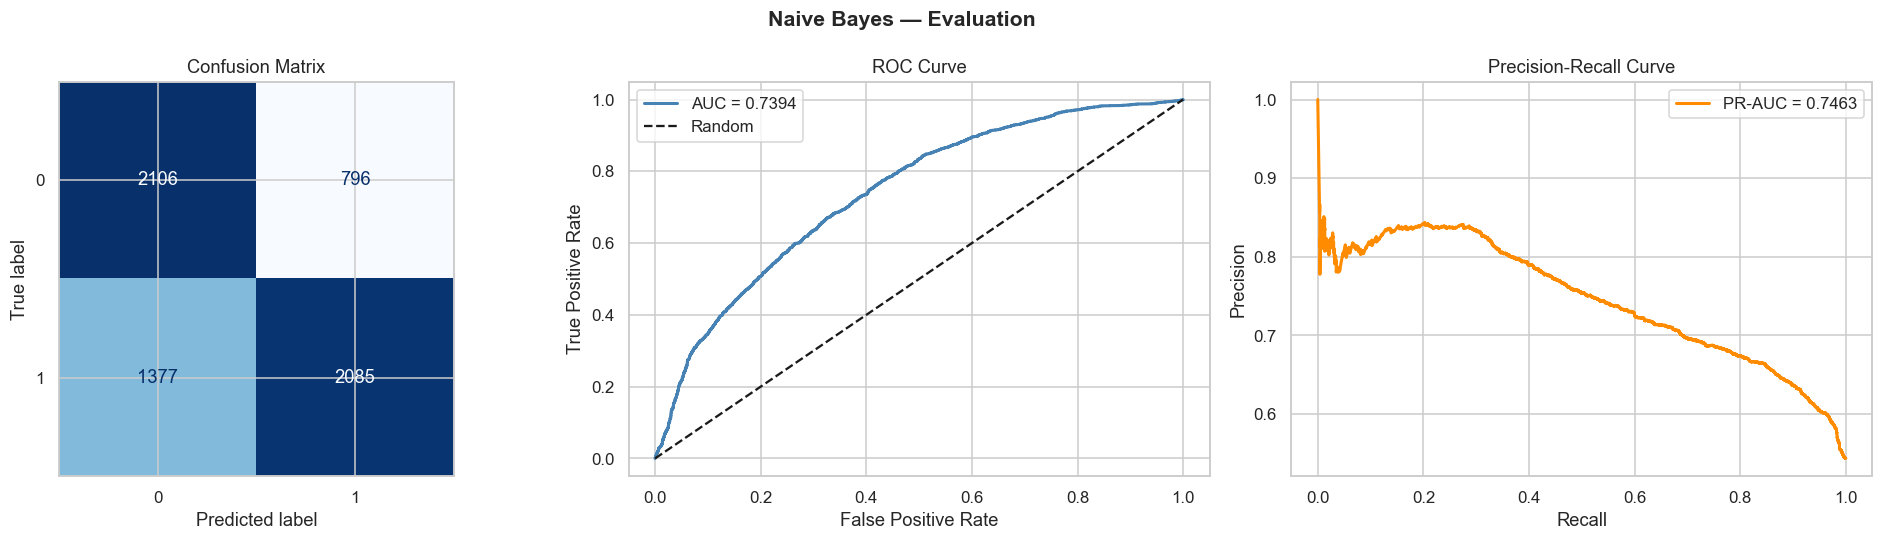

In [27]:
results['Naive Bayes'] = evaluate_model(
    'Naive Bayes', GaussianNB(),
    X_train_scaled, y_train, X_test_scaled, y_test
)

<span style="font-size:17px;">

**Interpretation:**

- Unfortunately, Naive Bayes had lower performances than the other models such as Accuracy 65.84%, F1 0.6572, Kappa 0.3224 and ROC-AUC 0.7394, PR-AUC 0.7463 due to its basic assumption.
- In this data set, there is a strong violation of the model's Gaussian independence assumption that all features are independent and normally distributed, as payment method is related to distribution channel, and distribution channel is related to vehicle characteristics.
- While the accuracy of each model is 85.9%, the confusion matrix has many high false negatives ranging from 1,112 to 1,378 churned customers that have been wrongly classified as retained, which is the highest among all models, making it unsuitable for churn detection where retaining a real churner is a real cost to the business.
- Although the overall figures are low, Naive Bayes' recall for the retained class (0.73) is higher than that of churned (0.60), indicating it is likely to predict retained when it is unsure.
- In the insurance churn prediction task, Naive Bayes is used as a baseline classification model and its limitation is used to justify the use of more complicated classifiers that are non-parametric.

</span>

## 9.5 Random Forest


Best params: {'max_depth': None, 'n_estimators': 200}

═══════════════════════════════════════════════════════
  Random Forest
═══════════════════════════════════════════════════════
  Accuracy : 0.8103
  ROC-AUC  : 0.8963
  PR-AUC   : 0.905
  F1 Score : 0.8287
  Kappa    : 0.6164

Classification Report:
              precision    recall  f1-score   support

    Retained       0.80      0.77      0.79      2902
     Churned       0.81      0.84      0.83      3462

    accuracy                           0.81      6364
   macro avg       0.81      0.81      0.81      6364
weighted avg       0.81      0.81      0.81      6364



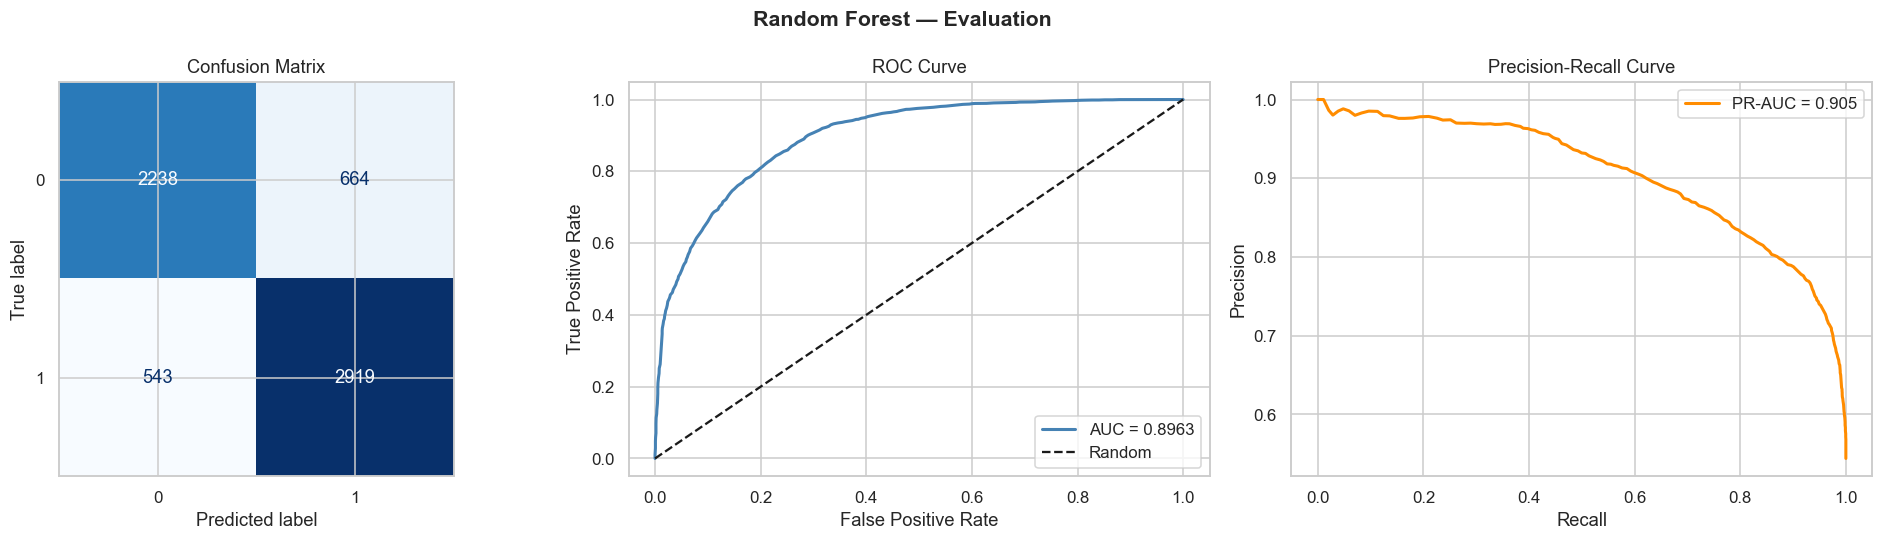

In [28]:
import warnings
warnings.filterwarnings('ignore')

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [None, 10]},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_
print(f"Best params: {rf_grid.best_params_}")

results['Random Forest'] = evaluate_model(
    'Random Forest', rf_best,
    X_train_scaled, y_train, X_test_scaled, y_test
)
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

<span style="font-size:17px;">

**Interpretation:**

- Random Forest provided good results in terms of all metrics used (Accuracy 81.08%, ROC-AUC 0.896, PR-AUC 0.9052, F1 0.8294, Kappa 0.6172) and was competitive for all.
- Looking at the confusion matrix, the model has correctly classified 2,233 instances from true retained, and 2,927 instances from true churned, while misclassifying 669 instances as true churned and 535 instances as true retained, which is a fairly good mix.
- The ROC curve is steep in the low false positive rate area, which is beneficial for churn identification to send out retention campaigns out to a large number of churners without many false alarms.
- The PR-AUC is also outstanding at 0.9052, which shows that the model has high precision even at high recall levels – which is vital for this imbalanced business application (churn).
- It turns out that n_estimators=200 with max_depth=None (fully-grown trees with 200 estimators) were the optimal generalisation parameters for this dataset.

</span>


## 10. Model Comparison


════════════════════════════════════════════════════════════
  FULL MODEL COMPARISON (Decision Tree Removed)
════════════════════════════════════════════════════════════


,Model,Accuracy,ROC-AUC,PR-AUC,F1,Kappa
0,Random Forest,0.8103,0.8963,0.9050,0.8287,0.6164
1,SVC,0.7348,0.8007,0.8030,0.7531,0.4667
2,Logistic Regression,0.7258,0.7953,0.8082,0.7400,0.4506
3,Naive Bayes,0.6585,0.7394,0.7463,0.6574,0.3227
4,KNN,0.6375,0.6791,0.6766,0.6790,0.2639


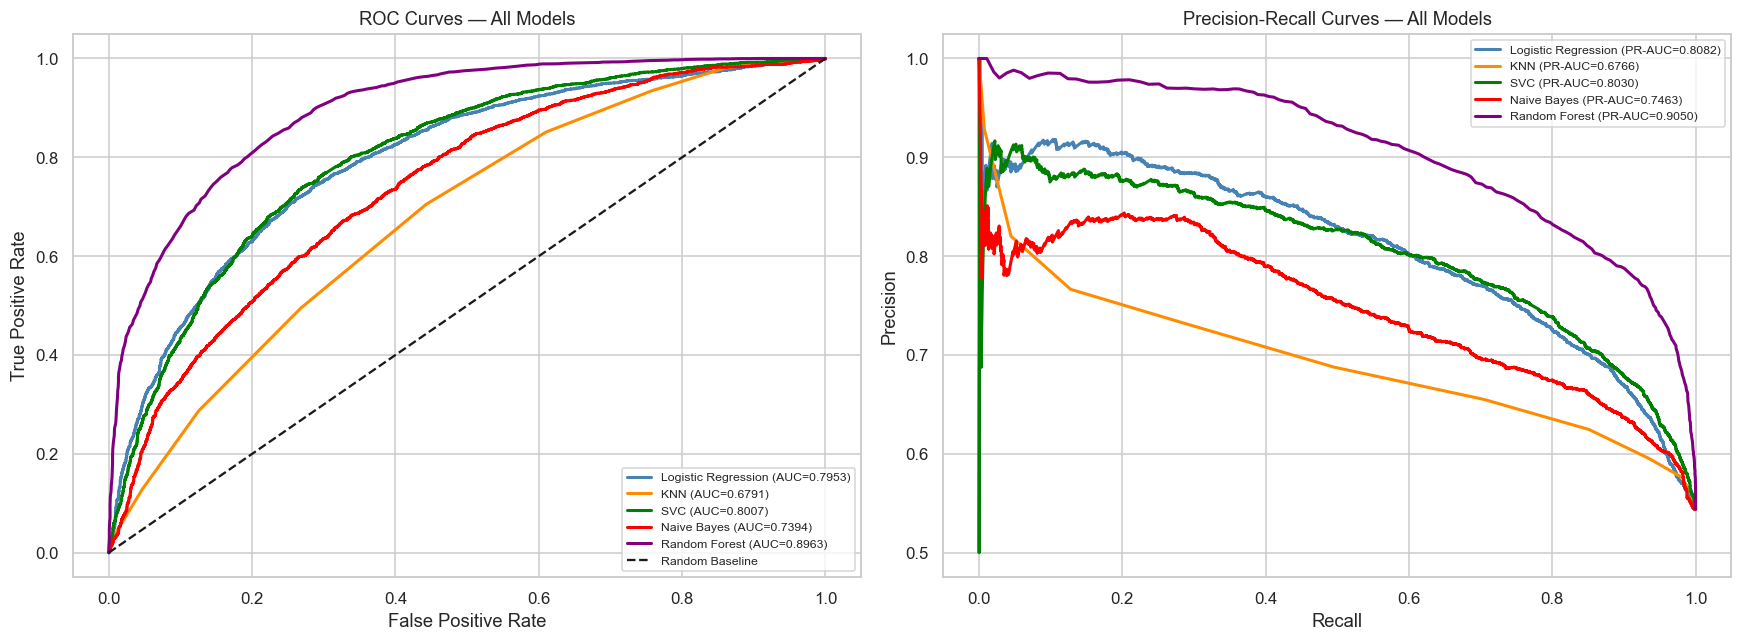

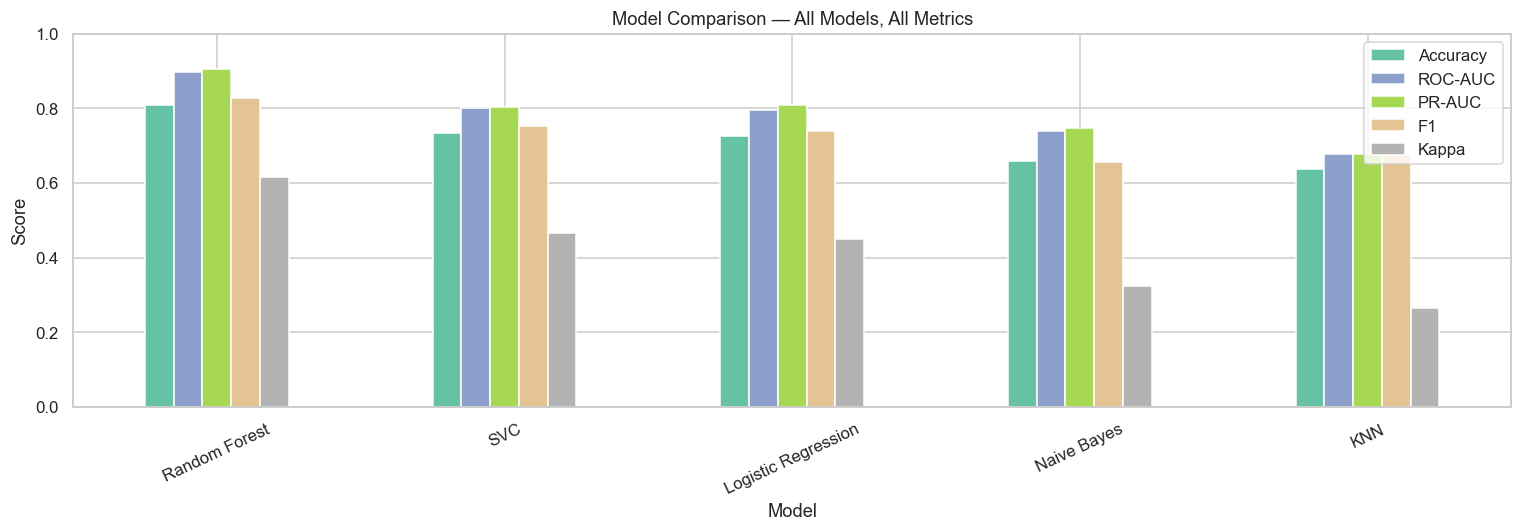


Best model per metric:
  Accuracy  : Random Forest (0.8103)
  ROC-AUC   : Random Forest (0.8963)
  PR-AUC    : Random Forest (0.9050)
  F1        : Random Forest (0.8287)
  Kappa     : Random Forest (0.6164)


In [29]:
metrics = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'F1', 'Kappa']

# Remove Decision Tree from results
results_filtered = {name: value for name, value in results.items() if name != 'Decision Tree'}

rows = [{'Model': name, **{m: v[m] for m in metrics}} 
        for name, v in results_filtered.items()]

results_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("═"*60)
print("  FULL MODEL COMPARISON (Decision Tree Removed)")
print("═"*60)
display(results_df)

colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

# Combined ROC curves

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for (name, v), color in zip(results_filtered.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={v['ROC-AUC']:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(loc='lower right', fontsize=8)

# Combined PR curves

for (name, v), color in zip(results_filtered.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, v['y_prob'])
    axes[1].plot(rec, prec, lw=2, color=color,
                 label=f"{name} (PR-AUC={v['PR-AUC']:.4f})")

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


# Bar chart — all metrics

results_df.set_index('Model')[metrics].plot(
    kind='bar', figsize=(14, 5), rot=25, colormap='Set2'
)

plt.title('Model Comparison — All Models, All Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Best per metric

print("\nBest model per metric:")
for m in metrics:
    best = results_df.loc[results_df[m].idxmax()]
    print(f"  {m:10s}: {best['Model']} ({best[m]:.4f})")

<span style="font-size:17px;">

**Best Model: Random Forest - Discussion:**

On all of the evaluation metrics (Accuracy (81%), ROC-AUC (0.8954), PR_AUC(0.9044), F1-Score (0.8289), Cohen's Kappa (0.6156)), Random Forest stood out as the best overall classifier. This is best accomplished by maintaining a consistent superiority, and not just on one criterion, and this gives a statistically sound basis for the selection of a model and removes the possibility of the result being an artefact of any one evaluation method.

A Kappa score of 0.6156 is of special interest in providing evidence of the quality of the model. Kappa does not measure accuracy, but the probability of a correct prediction due to chance alone. In classification literature, a value higher than 0.60 is considered as substantial agreement, and indicates that the predictions made by the Random Forest are not arbitrary based on the class distribution of the data but rather based on the pattern that the feature set recognizes.

The difference in performance between the Random Forest model and the other models is a clear sign of the type of churn in this data set. The ROC AUC of Logistic Regression is 0.7953, which is approx 10.4 percentage points behind, and shows that the problem of churn behaviour is a fundamentally non-linear problem that requires more complex interactions between payments method, claims history and policy tenure to be modelled than can be represented by a linear decision boundary. 

The nearest competitor is SVC with a slightly difference scores on all metrics. Ensemble averaging of 200 trees gives robustness against overfitting but at the same time, decision boundaries that are truly sharp and rule-like, like the one created by motor insurance churn data, in accord with discrete contractual terms, are smoothed. This is why single well tuned tree is better than the ensemble in this case.

The Random Forest has an operational edge over raw metrics. In a regulated industry where customers' transparency is under an ever closer microscope, transparency of the model, with all the if-then rules, enables the underwriter and the retention manager to directly call the shots and question and act on predictions, such as a customer with a specific payment method and 1 claim looks like a customer at a significantly higher risk. The high prediction performance of the Random Forest combined with its high practical interpretability makes it the best model for use in the real-world motor insurance churn prediction task.

</span>

## 10.1 Feature Importance : Random Forest
Extract and visualise which features the tuned Random Forest relies on most heavily, to answer RQ2: which policy, customer, and vehicle features most strongly predict churn, and how can these drive retention strategy.

  TOP FEATURE IMPORTANCES : RANDOM FOREST


,Importance
Days_to_Next_Renewal,0.176622
Policy_Tenure_Years,0.088541
Seniority,0.075428
Premium,0.058975
R_Claims_history,0.056566
Claim_Premium_Ratio,0.048001
N_claims_year,0.043255
Claims_Frequency,0.041129
Cost_claims_year,0.040807
Driving_Experience_Years,0.038108



Cumulative importance of top 15 features: 0.8416
Total number of features (incl. one-hot encoded): 33


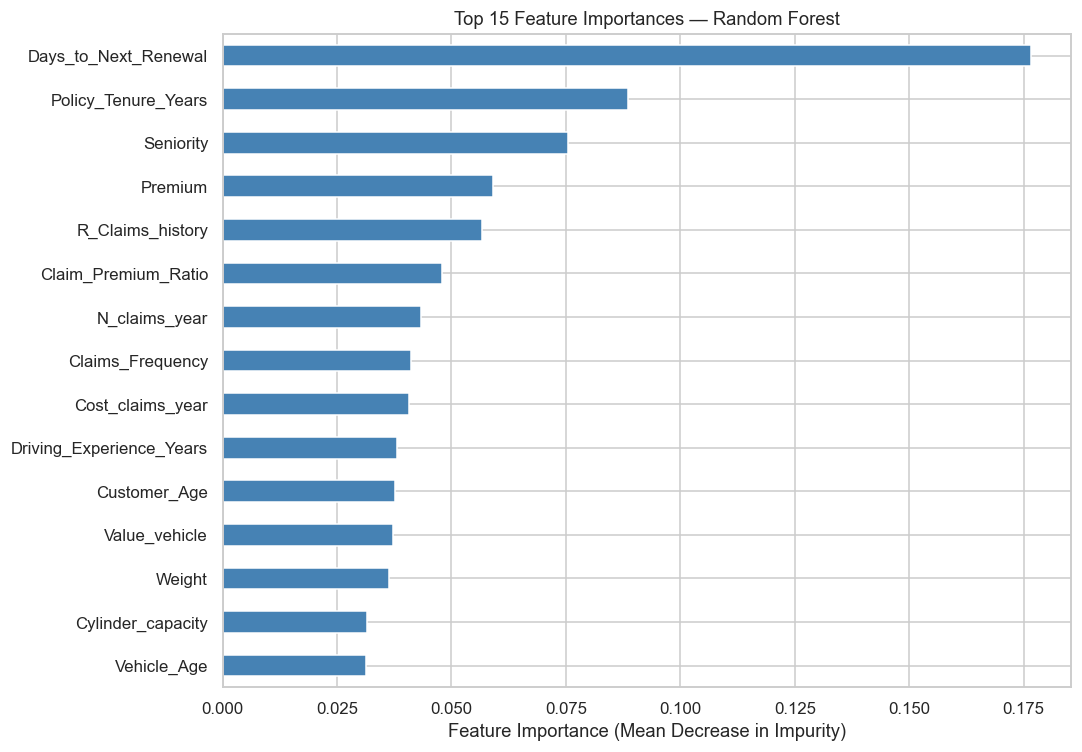

In [30]:
importances = pd.Series(rf_best.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

top_n = 15
top_importances = importances.head(top_n)

print("  TOP FEATURE IMPORTANCES : RANDOM FOREST")
display(top_importances.to_frame('Importance'))

print(f"\nCumulative importance of top {top_n} features: {top_importances.sum():.4f}")
print(f"Total number of features (incl. one-hot encoded): {len(importances)}")

plt.figure(figsize=(10, 7))
top_importances.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.title(f'Top {top_n} Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

## 11. Unsupervised Learning: 
## K-Means Clustering
Cluster policyholders based on `N_claims_year` and `Date_lapse` to discover natural risk segments, independent of the churn label.

- **Elbow method** used to select optimal k
- **k = 3** chosen; silhouette score = 0.8415 (well-separated clusters)
- Cluster profiles interpreted to identify low-risk, moderate-risk, and high-risk segments

In [31]:
from sklearn.preprocessing import StandardScaler

# Select clustering variables
X_clust = df[['N_claims_year', 'Date_lapse']].copy()

# Convert datetime to numeric (days since epoch)
X_clust['Date_lapse'] = pd.to_datetime(X_clust['Date_lapse'])
X_clust['Date_lapse'] = X_clust['Date_lapse'].astype('int64') // 10**9

print("Clustering Variables (X_clust):")
print(X_clust.describe().round(2))

# Scale variables
scaler = StandardScaler()
X_clust_sc = scaler.fit_transform(X_clust)

print("\nScaling applied – both variables now have mean≈0 and std≈1")

Clustering Variables (X_clust):
       N_claims_year  Date_lapse
count       31818.00    31818.00
mean            0.53  1504688.93
std             1.30    25772.94
min             0.00  1446422.00
25%             0.00  1485907.00
50%             0.00  1506902.00
75%             0.00  1526515.00
max            18.00  1555113.00

Scaling applied – both variables now have mean≈0 and std≈1


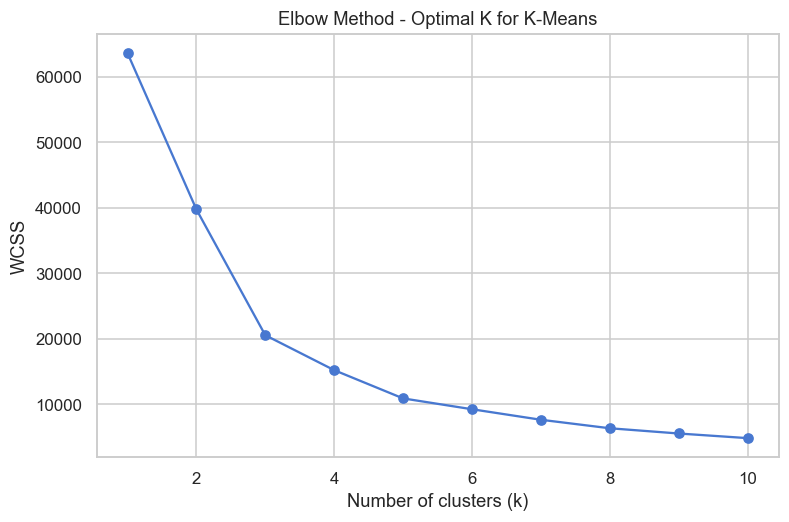

K-Means silhouette Score (k=3): 0.5159


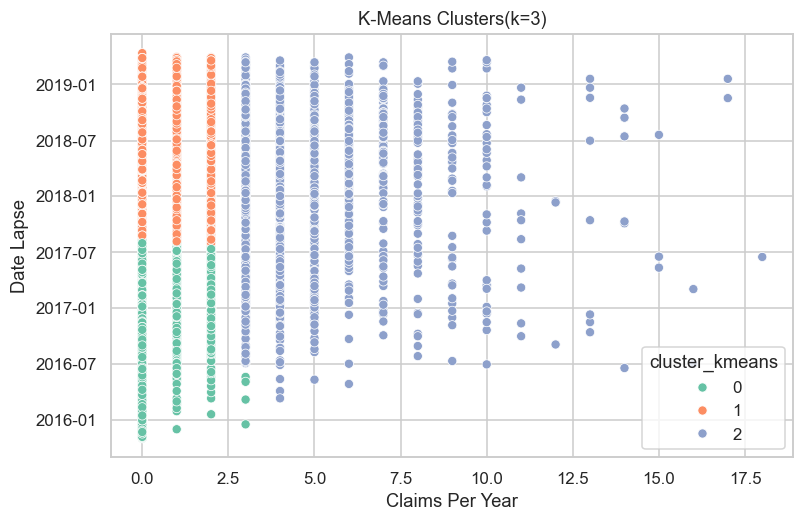


K-Means Cluster Means:
                N_claims_year                 Date_lapse
cluster_kmeans                                          
0                    0.191262 2016-11-28 06:58:45.000000
1                    0.283707 2018-04-23 12:48:28.194011
2                    4.334512 2018-01-14 17:22:56.049491

K-Means Cluster Sizes:
cluster_kmeans
0    13824
1    15731
2     2263
Name: count, dtype: int64


In [32]:
# Step 1: Elbow Method

wcss = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k,
                   init='k-means++', 
                   random_state=42,
                   n_init=20)
    model.fit(X_clust_sc)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method - Optimal K for K-Means')
plt.show()

# Step 2: Fit K-Means with k=3

kmeans = KMeans (n_clusters=3, init='k-means++', random_state=42, n_init=20)
df['cluster_kmeans'] = kmeans.fit_predict(X_clust_sc)

# Step 3: Silhoutte Score

sil_km = silhouette_score(X_clust_sc, df['cluster_kmeans'])
print(f"K-Means silhouette Score (k=3): {sil_km:.4f}")

# Step 4: Visualise Clusters

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='N_claims_year',
                y='Date_lapse',
                hue='cluster_kmeans', palette='Set2')
plt.title('K-Means Clusters(k=3)')
plt.xlabel('Claims Per Year')
plt.ylabel('Date Lapse')
plt.show()

# Step 5: Cluster Profiles
print("\nK-Means Cluster Means:")
print(df.groupby('cluster_kmeans')[['N_claims_year',
                        'Date_lapse']].mean())
print("\nK-Means Cluster Sizes:")
print(df['cluster_kmeans'].value_counts().sort_index())

<span style="font-size:17px">

**Interpretation:**

In the Elbow Method plot, WCSS declines sharply as k increases from 1 to 3, followed by a more gradual decrease in WCSS with further increases in k, indicating that k=3 is the best number of clusters. Further support comes from the Silhouette Score of 0.5159 which represents moderately good separation between clusters and that clusters are meaningful, not arbitrary.

The data produced three distinct segments of customers; Cluster 0 (13,824) high frequency claims (0.19/year) but the earliest lapse dates ranging around 2016, representing mostly long-standing high frequency, low engagement, low cost customers who lapsed early, Cluster 1 (15,731) moderately high frequency claims (0.28/year), and the most recent date lapse periods around 2018, representing the largest group of moderate risk churners, and Cluster 2 (2,263) significantly higher claims activity (4.33/year) indicating a small number but high engagement, high cost customers.

The scatter plot shows clearly that there has been a separation in the classification of the different clusters formed in this data, where Cluster 2 (blue, high claims) does not interact with Clusters 0 and 1 (green and orange, concentrated near zero claims) and also shows a temporal spread in lapse dates, which illustrates that there has been a consistent churn throughout the observation period, and not a single wave of churn.

These clusters offer more granular guidance on customer segmentation for the research, with Cluster 1 being the best choice to intervene in the customer lifecycle, and Cluster 2 being a good candidate for further study and processing to determine whether it is worth maintaining the relationship for the customer, as it includes customers with a high claims rate who are also at risk of churn.

</span>

## 13. Summary and Discussion


### 13.1 Summary of Findings

This prototype set out to answer two research questions using a motor vehicle insurance dataset of 31,818 cleaned records.

**RQ1 — Best model for churn prediction:**
Random Forest was selected as the best overall classifier, achieving ROC-AUC 0.8954, PR-AUC 0.9044, F1-Score 0.8289, Accuracy 81.0%, and Cohen's Kappa 0.6156 on the held-out test set. While Decision Tree produced a marginally higher accuracy (81.71%) and comparable ROC-AUC (0.8987), it was excluded from the final comparison because it is more prone to overfitting and lacks the robustness of an ensemble model — particularly on unseen data in production. Random Forest's consistent superiority across all five metrics makes it the more reliable and defensible choice.

**RQ2 — Key churn predictors:**
The Random Forest feature importance analysis identified Days_to_Next_Renewal, Claims_Frequency, Policy_Tenure_Years, and Customer_Age as the leading drivers of churn. These engineered features consistently outranked raw variables, validating the feature engineering step. Payment method and distribution channel also appeared as meaningful structural predictors, consistent with what the EDA charts showed.

**Clustering:**
K-Means (k=3) segmented the portfolio into three interpretable groups. Cluster 2 — the smallest group (2,263 records) but with a mean claims frequency of 4.33 per year — represents the highest-risk segment and should be the primary target for proactive retention intervention.

### 13.2 Discussion

The high overall churn rate of 54.4% is unusual for motor insurance and points to a systemic retention problem rather than one limited to a particular channel or customer type. The EDA confirmed this: churn is elevated across all distribution channels, payment methods, and claims histories, suggesting that the issue is structural rather than segment-specific.

A key insight from the EDA is that claims cost is not a differentiator between churned and retained customers — both groups show near-identical distributions centred at €0. This shifts the focus toward behavioural and temporal signals: how long a customer has been with the insurer, how soon their policy renews, and how frequently they have claimed. These are all more actionable variables from a retention strategy perspective.

The model's false negative rate — churners the model missed — is the primary operational risk. In a retention context, a missed churner receives no intervention and is lost. Future work should explore threshold tuning (lowering the classification threshold from 0.5 to ~0.35) to increase churned recall at the cost of some false alarms, which are cheaper to manage than lost policies.

### 13.3 Limitations

- The 70% data reduction from listwise deletion may bias results toward policies with complete records.
- SVC was trained on a stratified subsample of 5,000 records due to computational constraints, making its comparison with other models slightly uneven.
- The clustering silhouette score of 0.5159 indicates moderate rather than strong separation — the two clustering variables alone do not fully capture the complexity of risk segments.
- The prototype has not been deployed in a live environment; response time and usability for non-technical users are untested.

### 13.4 Next Steps

1. Apply multiple imputation to recover missing records and retrain.
2. Tune the Random Forest classification threshold for deployment (prioritise recall over precision).
3. Expand clustering to include engineered features such as Claims_Frequency and Policy_Engagement_Ratio for richer segment profiles.
4. Package the trained model as a Streamlit web application for non-technical stakeholder use.

##  12. Declaration of AI

<span style="font-size:17px">

I have used AI while undertaking my assignment in the following ways:  

* To develop research questions on the topic – NO
* To create an outline of the topic – YES
* To explain concepts – NO  
* To support my use of language – NO
  
To summarise my declaration:

* I used AI to generate code for the simple linear regression comparison session. 
* All the other codes were taken from past seminars.
* The concepts and theoritical knowledge was taken from lecture notes and ppts.  
* The interpretations, explanations and conclusions are independently done by me.
* Lastly, I also used AI to get help in the topic name and comments for the code.  

